In [51]:
import pandas as pd
import yaml
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from pathlib import Path

In [52]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn

In [53]:
model_version = '1_0_5'
chunk_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/v{model_version}_standard_global/'
parquet_name = f'veg_model_zonal_stats_v{model_version}_20260224_19_21_07.parquet'

In [54]:
%%time

# Reads gross outputs parquet table
df_graphs = pd.read_parquet(f'{chunk_stats_folder}{parquet_name}')
df_graphs["WDPA_high_protection"] = df_graphs["WDPA"].isin([1, 2, 3]).astype(int)
df_graphs["country_name"] = df_graphs["country_name"].replace({
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

print(f"Rows in df: {len(df_graphs)}")
# df_graphs

Rows in df: 27999047
CPU times: user 35.1 s, sys: 5.55 s, total: 40.6 s
Wall time: 10.9 s


In [55]:
%%time

layers_to_drop = [
    "carbon_density__non_soil__MgC_ha",
    cn.agc_gross_emis_pattern,
    cn.bgc_gross_emis_pattern,
    cn.deadwood_c_gross_emis_pattern,
    cn.litter_c_gross_emis_pattern,
    cn.net_flux_all_C_pools_CO2_only_pattern,
    cn.agc_gross_removals_pattern,
    cn.bgc_gross_removals_pattern,
    cn.deadwood_c_gross_removals_pattern,
    cn.litter_c_gross_removals_pattern,
    cn.net_flux_agc_pattern,
    cn.net_flux_bgc_pattern,
    cn.net_flux_deadwood_c_pattern,
    cn.net_flux_litter_c_pattern,
    cn.ch4_gross_emis_pattern,
    cn.n2o_gross_emis_pattern
]

df_graphs = df_graphs[~df_graphs["analysis_layer"].isin(layers_to_drop)].reset_index(drop=True)
print(f"Rows in df: {len(df_graphs)}")
# df_graphs

Rows in df: 8178188
CPU times: user 2.44 s, sys: 1.28 s, total: 3.73 s
Wall time: 3.7 s


Figure creation

In [56]:
# Legend text

gross_emis_all_gases_legend = "Gross emissions (all gases)"
gross_emis_CO2_legend = "Gross emissions (CO₂ only)"
gross_emis_non_CO2_legend = "Gross emissions (non-CO₂)"
net_flux_all_gases_legend = "Net flux (all gases)"
gross_removals_legend = "Gross removals"

broad_class_dict = {
    "tree": "Tall vegetation",
    "short_veg": "Short vegetation",
    "crop": "Cropland"
}

detailed_class_dict = {
    "tree_tree_undisturbed": "Undisturbed tall veg (except for fires)",
    "tree_tree_disturbed": "Partially disturbed tall veg", 
    "tree_loss": "Tall veg loss",
    "tree_gain": "Tall veg gain",
    "short_veg_short_veg_undisturbed": "Stable short veg",
    "short_veg_gain": "Short veg gain",
    "short_veg_loss": "Short veg loss", 
    "crop_crop_undisturbed": "Stable cropland",
    "crop_gain": "Cropland gain",
    "crop_loss": "Cropland loss"
}

tall_classes = [
    "Tall veg loss",
    "Tall veg gain",
    "Partially disturbed tall veg",
    "Undisturbed tall veg (except for fires)"
]

# Aggregates by analysis layer
def aggregate_layer(df, pattern):
    d = df[df["analysis_layer"] == pattern]
    d = (
        d.groupby([context_to_analyze, "year"], as_index=False)
         .agg({"value": "sum"})
    )
    d["value_Gt"] = d["value"] / 1e9
    return d

In [57]:
sns.set_theme(style="white", context="talk")

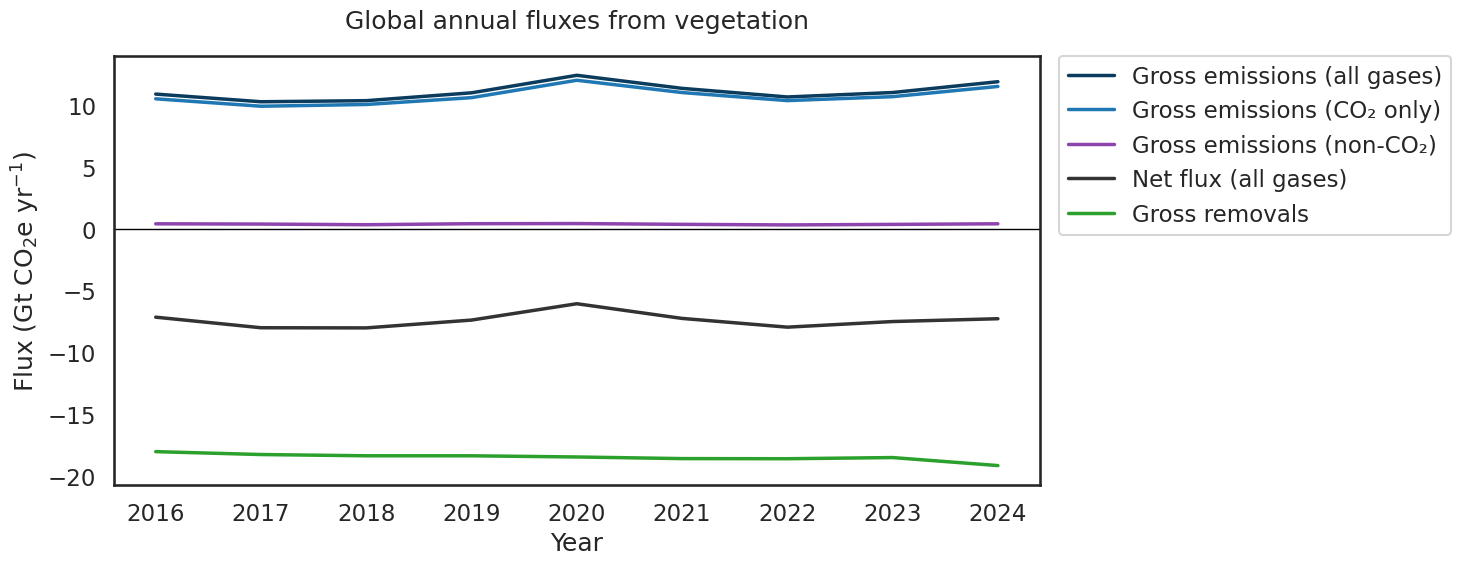

In [58]:
### Global emissions, removals, net flux timeseries (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

df_fig = df_graphs.copy()

df_ts = (
    df_fig
    .groupby(["analysis_layer", "year"], as_index=False)
    .agg({"value": "sum"})
)

# Convert to Gt CO2e
df_ts["value_Gt"] = df_ts["value"] / 1e9

layer_labels = {
    cn.gross_emis_all_C_pools_CO2_only_pattern:
        gross_emis_CO2_legend,
    cn.gross_emis_all_C_pools_non_CO2_only_pattern:
        gross_emis_non_CO2_legend,
    cn.gross_emis_all_C_pools_all_gases_pattern:
        gross_emis_all_gases_legend,
    cn.gross_removals_all_C_pools_pattern:
        gross_removals_legend,
    cn.net_flux_all_C_pools_all_gases_pattern:
        net_flux_all_gases_legend,
}

# Custom color mapping aligned with desired_order
custom_palette = {
    gross_emis_all_gases_legend: "#0b3c5d",      # deep navy
    gross_emis_CO2_legend: "#1f77b4",       # strong blue
    gross_emis_non_CO2_legend: "#8e44ad",        # saturated violet
    net_flux_all_gases_legend: "#333333",             # charcoal (neutral emphasis)
    gross_removals_legend: "#2ca02c",                   # green
}

df_ts["layer_label"] = df_ts["analysis_layer"].map(layer_labels)

# Desired legend order
desired_order = [
    gross_emis_all_gases_legend,
    gross_emis_CO2_legend,
    gross_emis_non_CO2_legend,
    net_flux_all_gases_legend,
    gross_removals_legend,
]

# Make categorical with order
df_ts["layer_label"] = pd.Categorical(
    df_ts["layer_label"],
    categories=desired_order,
    ordered=True
)

plt.figure(figsize=(15, 6))

ax = sns.lineplot(
    data=df_ts,
    x="year",
    y="value_Gt",
    hue="layer_label",
    hue_order=desired_order,
    palette=custom_palette,
    linewidth=2.5
)

# Zero reference line
ax.axhline(0, color="black", linewidth=1)

# Remove any gridlines
ax.grid(False)

ax.set_xlabel("Year")
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")

# Title
ax.set_title("Global annual fluxes from vegetation", pad=20)

# Legend outside right
ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

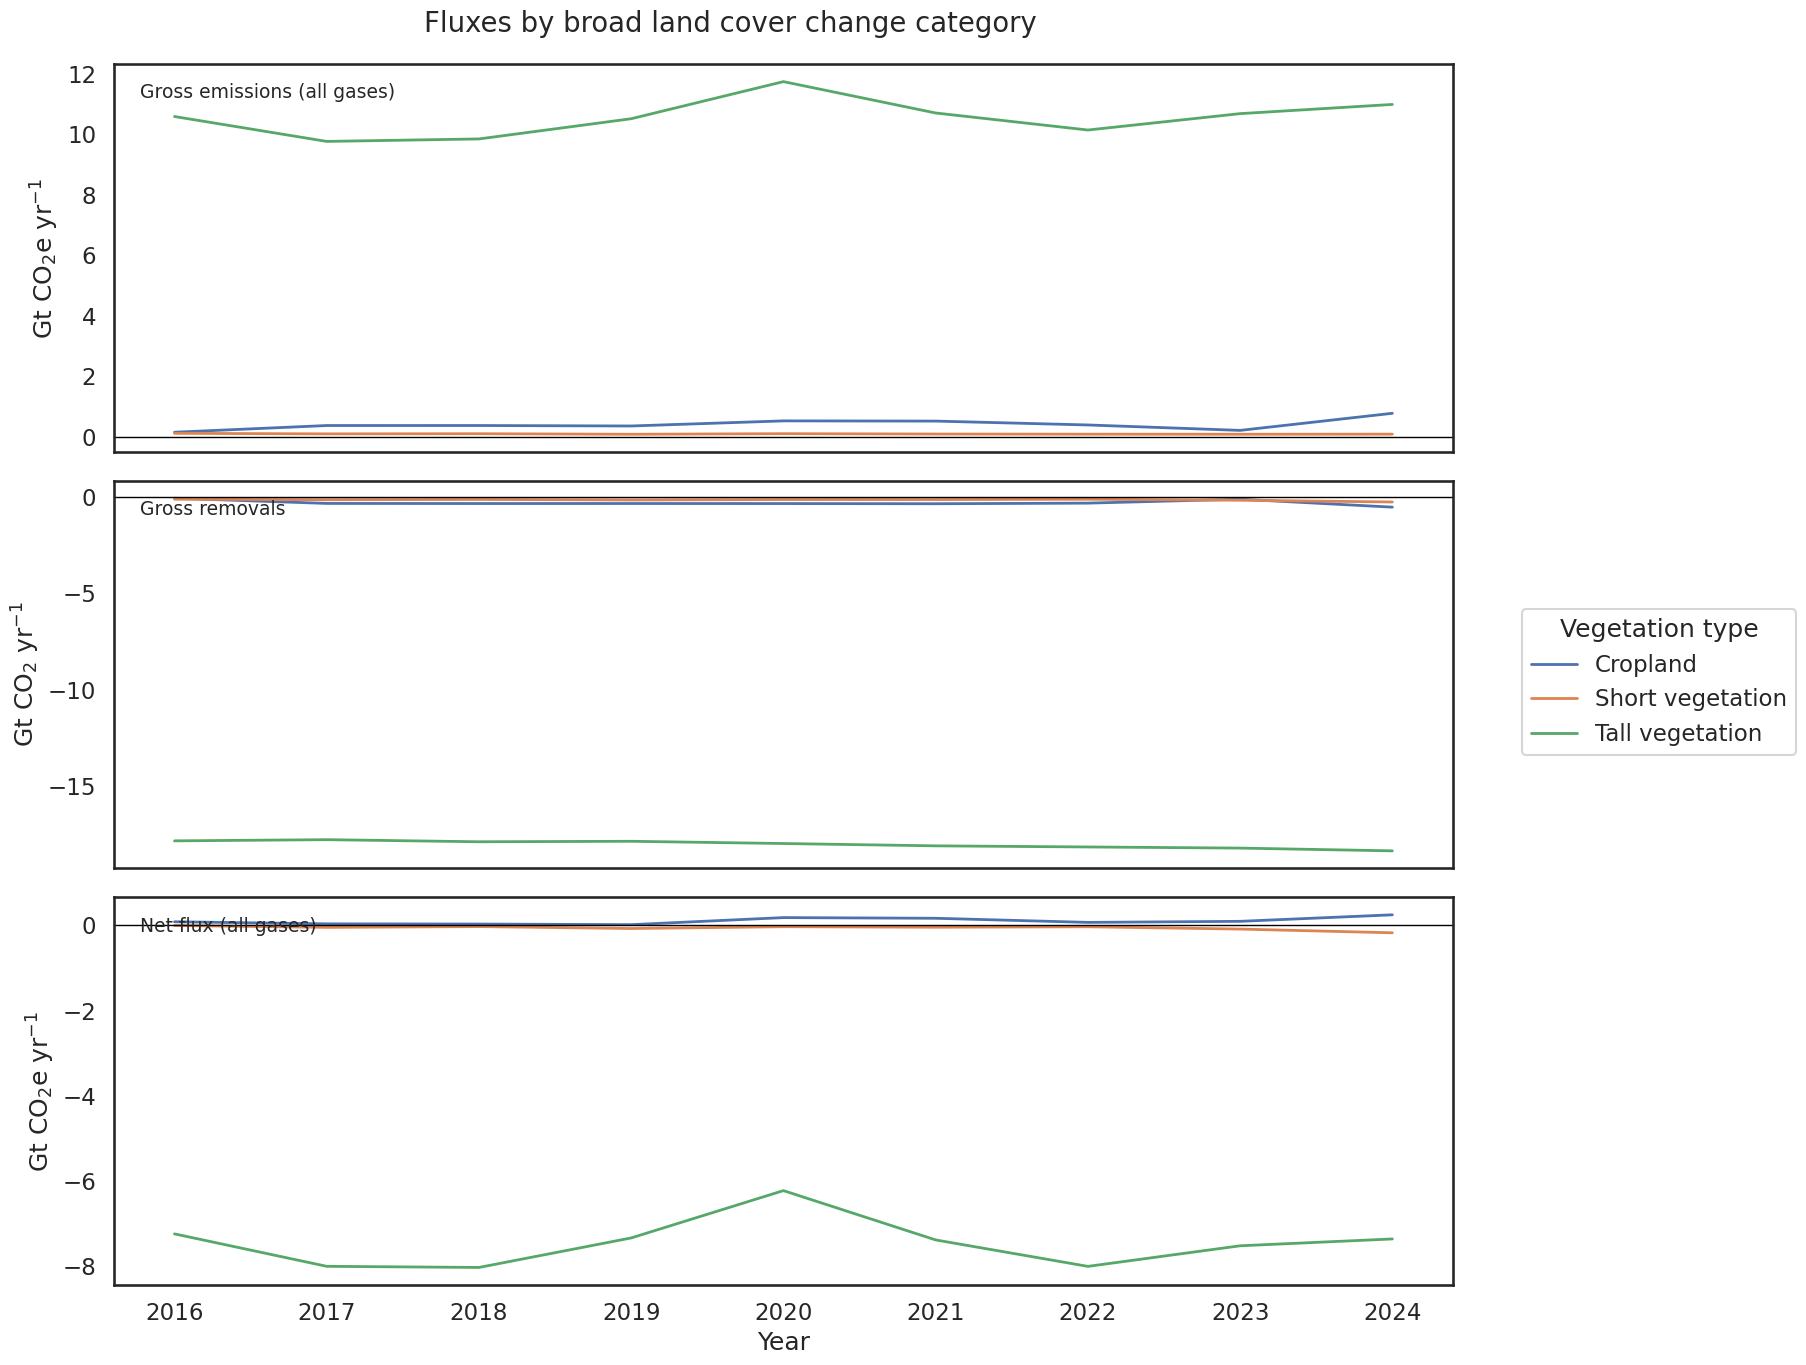

In [59]:
### Global emissions, removals, net flux timeseries by vegetation type (flux per panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'land_state_broad_class'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

df_fig = df_graphs.copy()

df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# Map to interpretable labels
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(broad_class_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(broad_class_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(broad_class_dict)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=False
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel("Year")

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Vegetation type",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[0].legend().remove()

fig.suptitle(
    "Fluxes by broad land cover change category",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

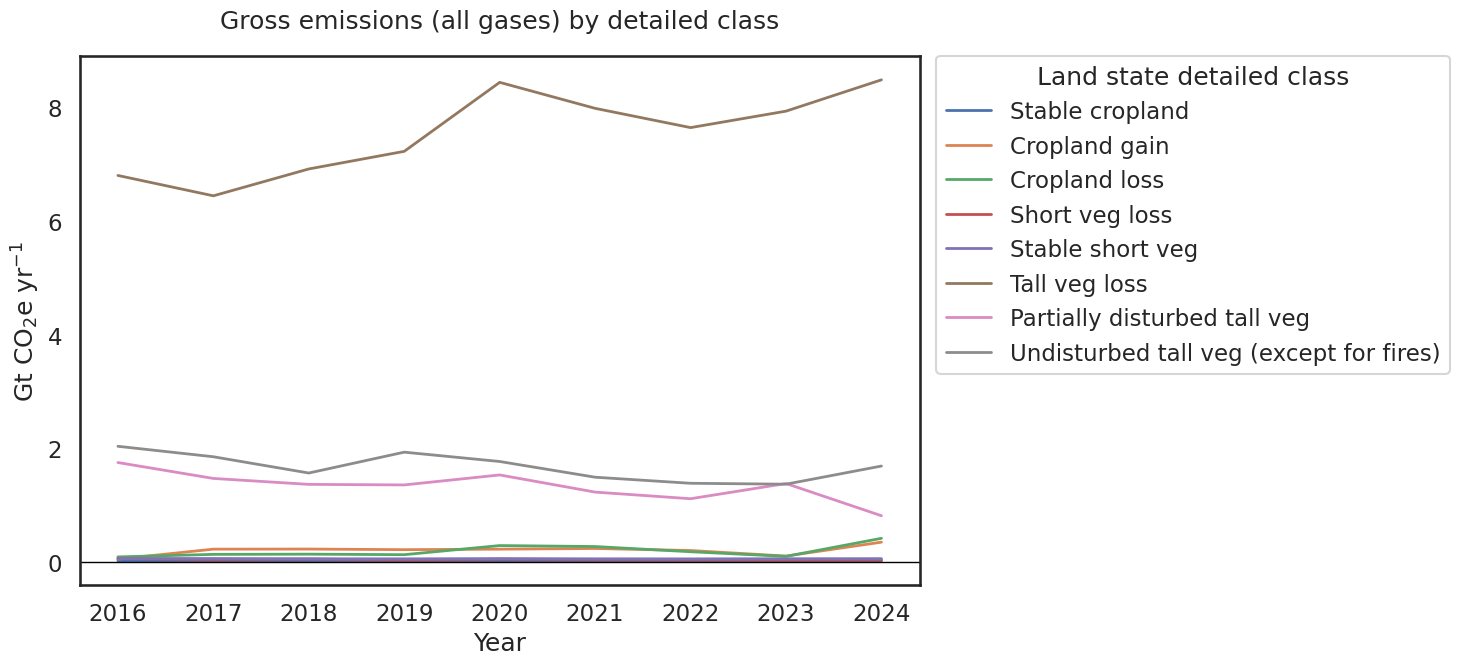

In [60]:
### Global gross emissions timeseries by 10 land cover change categories (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = "land_state_detailed_class"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
]

# Aggregate
df_emis_ts = (
    df_emis
    .groupby([context_to_analyze, "year"], as_index=False)
    .agg({"value": "sum"})
)

df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

# Map to readable labels
df_emis_ts["legend_label"] = df_emis_ts[context_to_analyze].map(detailed_class_dict)

# If some classes are missing from dictionary, keep original
df_emis_ts["legend_label"] = df_emis_ts["legend_label"].fillna(
    df_emis_ts[context_to_analyze]
)

# ---- Plot ----
sns.set_theme(style="white", context="talk")

plt.figure(figsize=(15, 7))

ax = sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="legend_label",
    linewidth=2
)

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel("Year")
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases) by detailed class", pad=20)

# Legend outside right
ax.legend(
    title="Land state detailed class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

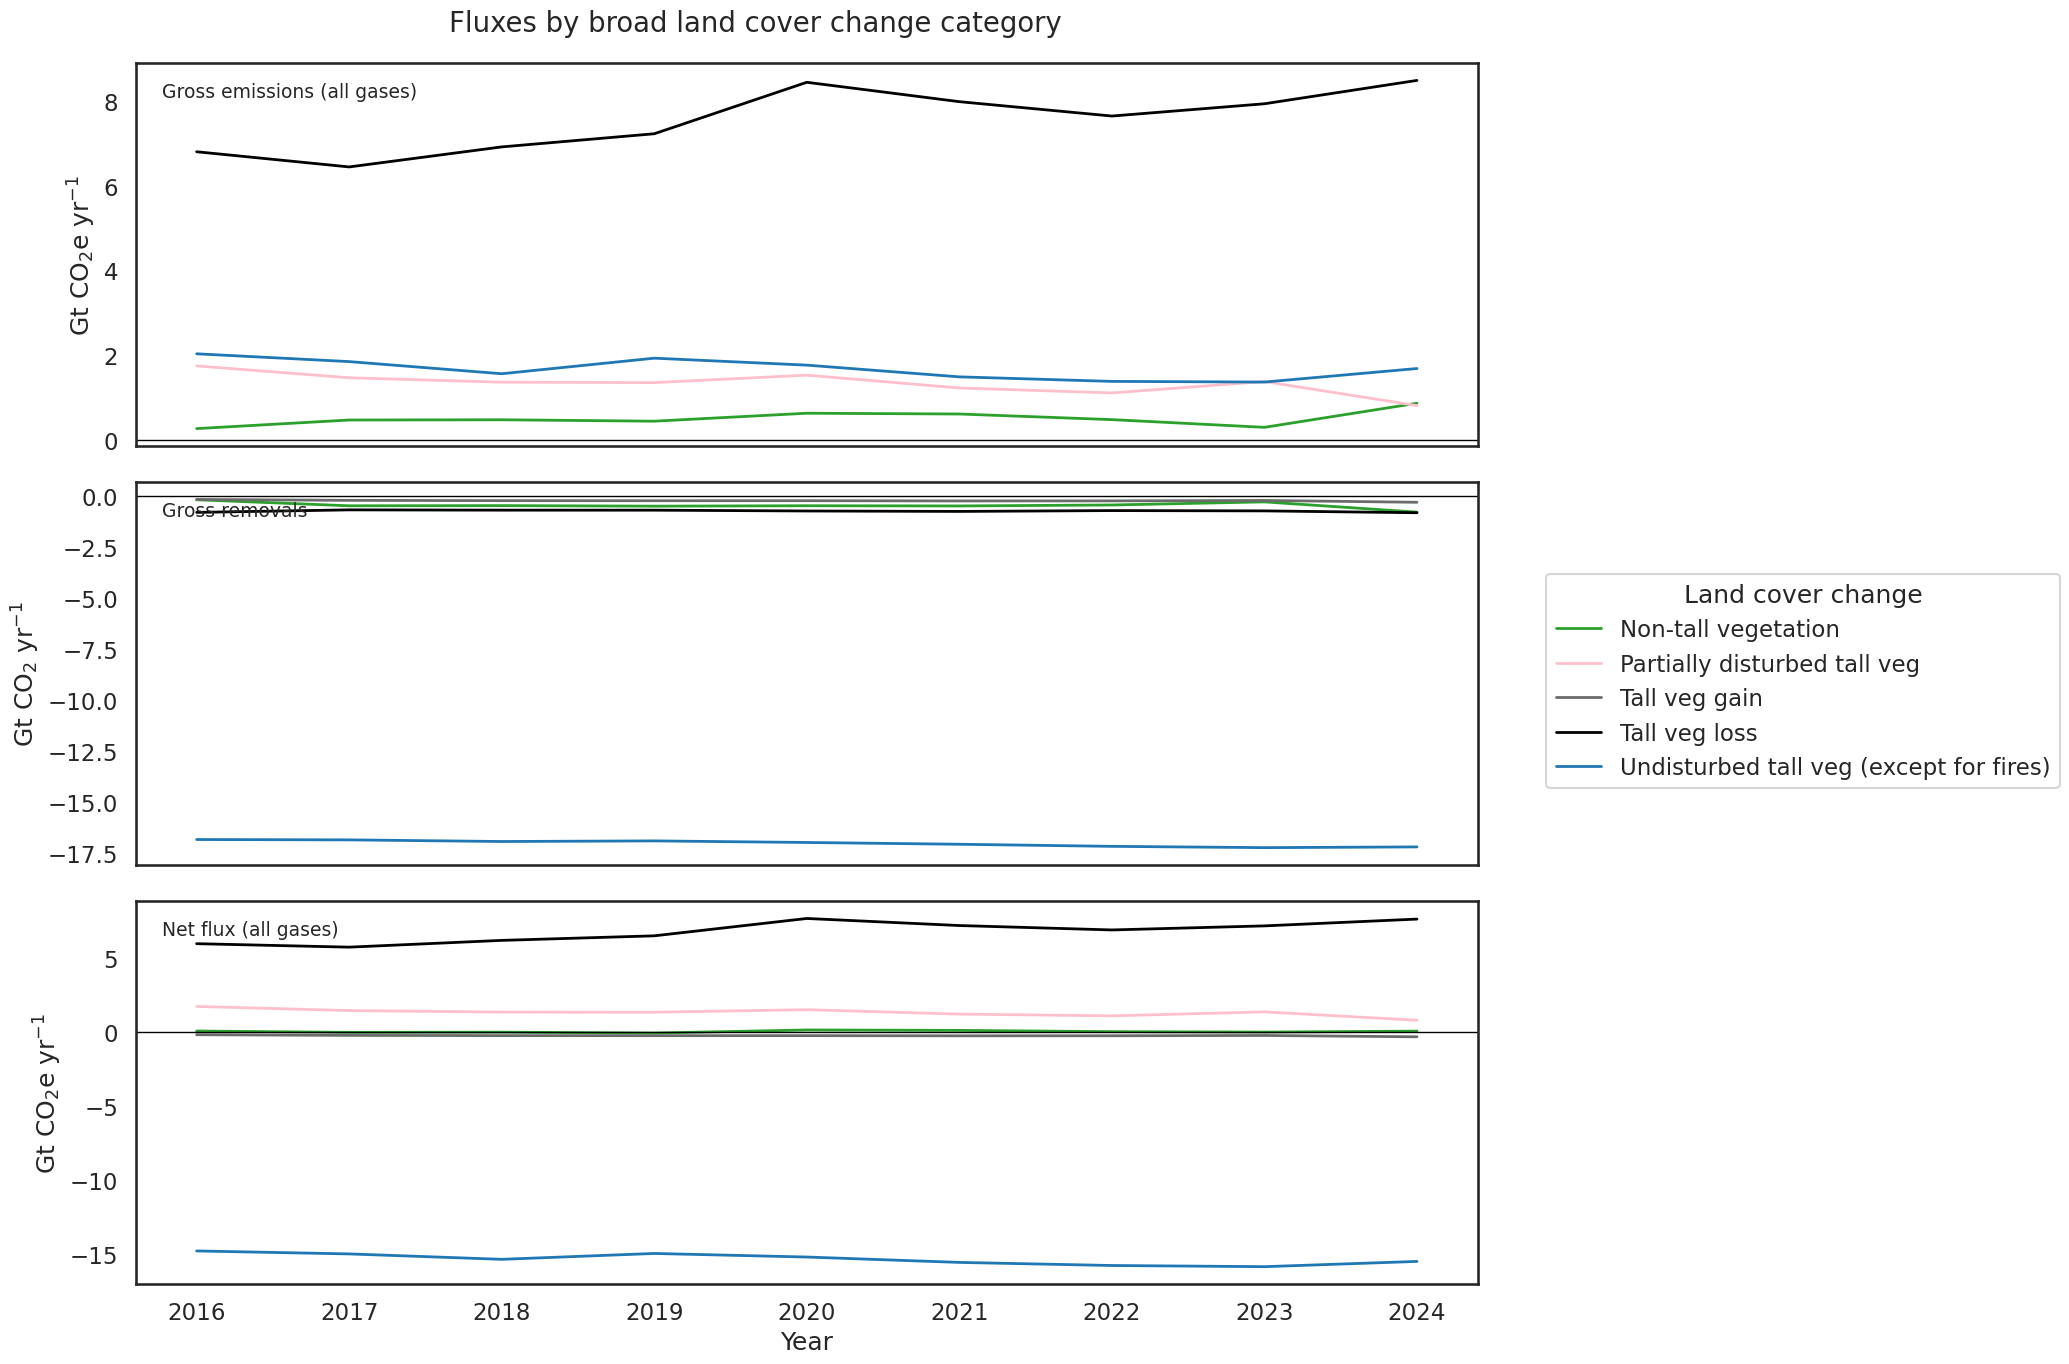

In [61]:
### Global emissions, removals, net flux timeseries by 4 landcover change categories (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'land_state_detailed_class'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
# detailed_class_palette = {
#     "Tall veg loss": "#000000",                     # black
#     "Tall veg gain": "#999999",                     # ?
#     "Partially disturbed tall veg": "#d62728",      # red
#     "Undisturbed tall veg (except for fires)": "#1f77b4",  # blue
#     "Stable short veg": "#2ca02c",                  # green
#     "Short veg loss": "#8c564b",                    # brown
#     "Short veg gain": "#111111",                    # ?
#     "Stable cropland": "#9467bd",                   # purple
#     "Cropland gain": "#ff7f0e",                     # orange
#     "Cropland loss": "#7f7f7f",                     # gray
# }

# Palette for detailed classes with 
detailed_class_palette = {
    "Tall veg loss": "#000000",                     # black
    "Tall veg gain": "#6b6b6b",                     # dark gray
    "Partially disturbed tall veg": "#FFC0CB",      # pink
    "Undisturbed tall veg (except for fires)": "#1f77b4",  # blue
    "Non-tall vegetation": "#2ca02c",               # green
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# ---- Map to interpretable labels ----
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(detailed_class_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(detailed_class_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(detailed_class_dict)

# ---- Collapse to tall vs other ----
def collapse_to_tall_vs_other(df):
    df = df.copy()
    df[context_to_analyze] = df[context_to_analyze].apply(
        lambda x: x if x in tall_classes else "Non-tall vegetation"
    )
    return df

df_emis = collapse_to_tall_vs_other(df_emis)
df_remov = collapse_to_tall_vs_other(df_remov)
df_net = collapse_to_tall_vs_other(df_net)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=detailed_class_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel("Year")

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Land cover change",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by broad land cover change category",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

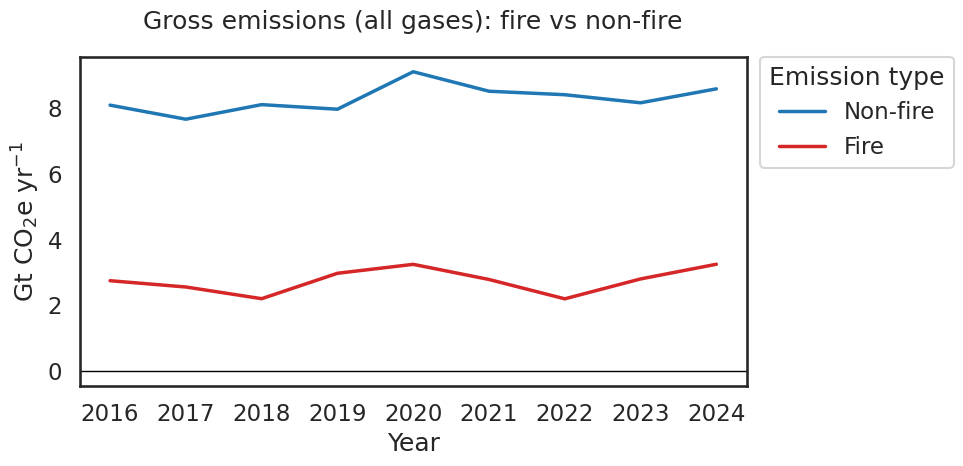

In [62]:
### Global gross emissions timeseries by fire vs. non-fire (single panel)

# ---- Setup ----
context_to_analyze = "land_state_node"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
].copy()

# ---- Reclassify fire vs non-fire BEFORE aggregation ----
df_emis["fire_class"] = df_emis[context_to_analyze].astype(str).apply(
    lambda x: "Fire" if re.search(r"9(0*)$", x) else "Non-fire"
)

# ---- Aggregate ----
df_emis_ts = (
    df_emis
    .groupby(["fire_class", "year"], as_index=False)
    .agg({"value": "sum"})
)

df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

plt.figure(figsize=(10, 5))

palette = {
    "Fire": "#d62728",      # red
    "Non-fire": "#1f77b4",  # blue
}

hue_order = ["Non-fire", "Fire"]

ax = sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="fire_class",
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5
)

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel("Year")
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases): fire vs non-fire", pad=20)

ax.legend(
    title="Emission type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

['Albania', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Czechia', 'Côte d Ivoire', 'DR Congo', 'Dominican Republic', 'East Timor', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'French Guiana', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Kenya', 'Korea', 'Korea (the Democratic Peoples Republic of)', 'Laos', 'Latvia', 'Liberia', 'Lithuania', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Mexico', 'Mongolia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'New Caledonia', 

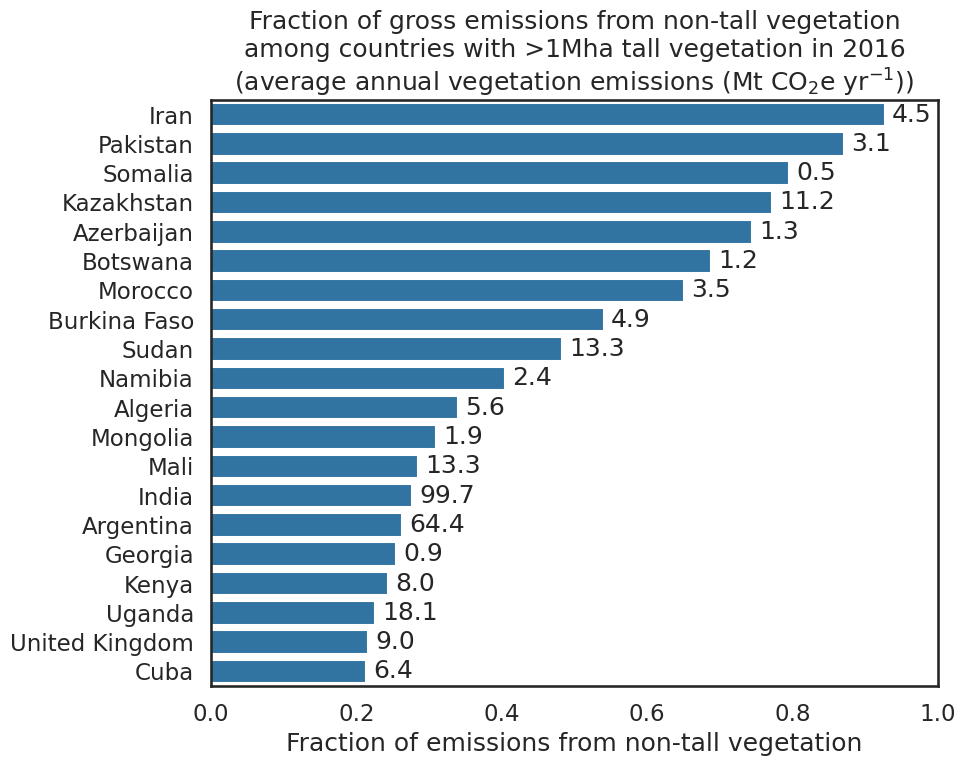

In [80]:
### Countries with >1 Mha "non-disturbed tall veg" in 2016 with the highest fraction of emissions from non-tall vegetation

## Determine which countries have enough forest area

min_area = 1_000_000

# New df for determining countries with large forest area
df_large_forest_area = df_graphs.copy()

# Restrict to undisturbed tall veg in 2016 (as proxy for forest area)
df_large_forest_area_2016 = df_large_forest_area[
    (df_large_forest_area["year"] == 2016) &
    (df_large_forest_area["land_state_detailed_class"] == "tree_tree_undisturbed") &
    (df_large_forest_area["analysis_layer"] == cn.net_flux_all_C_pools_all_gases_pattern)  # Need to use just one analysis layer to not double-count areas
]

# to_exp = df_large_forest_area[
#     # (df_large_forest_area["year"] == 2016) &
#     (df_large_forest_area["country_name"] == "Iran") &
#     (df_large_forest_area["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern)  # Need to use just one analysis layer to not double-count areas
# ]
# to_exp.to_csv("/mnt/c/GIS/test2.csv")

# Sums area for 2016 across all remaining contextual layer combinations
country_tree_tree_area_2016_total = df_large_forest_area_2016.groupby("country_name", as_index=False)['area_ha'].sum()
# print(country_tree_tree_area_2016_total.sort_values("area_ha", ascending=False).head(50))

# Apply 1 Mha threshold
eligible_countries = country_tree_tree_area_2016_total.loc[country_tree_tree_area_2016_total["area_ha"] > min_area, "country_name"].tolist()
print(eligible_countries)


## Calculate fraction of emissions from tall vegetation

# Filter to gross emissions (all gases)
df_emis = df_graphs[
    df_graphs["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
].copy()

# Map detailed class labels
df_emis["detailed_class"] = df_emis["land_state_detailed_class"].map(detailed_class_dict)

# Classify tall vs non-tall
df_emis["veg_group"] = df_emis["detailed_class"].apply(
    lambda x: "Tall_Mg_CO2e" if x in tall_classes else "Non-tall_Mg_CO2e"
)

# Sum across ALL YEARS by country and veg group
country_group_sum = (
    df_emis
    .groupby(["country_name", "veg_group"], as_index=False)
    .agg({"value": "sum"})
)
# print(country_group_sum)

# Pivot to wide format
country_wide = country_group_sum.pivot_table(
    index=["country_name"],
    columns="veg_group",
    values="value",
    fill_value=0
).reset_index()
# print(country_wide)

# Compute fraction
country_wide["total"] = country_wide.get("Tall_Mg_CO2e", 0) + country_wide.get("Non-tall_Mg_CO2e", 0)
country_wide["fraction_non_tall"] = (
    country_wide.get("Non-tall_Mg_CO2e", 0) / country_wide["total"]
)
# print(country_wide)

# Sort highest to lowest
country_ranked = country_wide.sort_values(
    "fraction_non_tall",
    ascending=False
)

# Limit results to countries with >1 Mha undisturbed tall veg in 2016
country_ranked_eligible = (
    country_ranked[
        country_ranked["country_name"].isin(eligible_countries)
    ]
    .sort_values("fraction_non_tall", ascending=False)
)

# Inspect top countries
print(country_ranked_eligible[[
    "country_name",
    "fraction_non_tall",
    "Non-tall_Mg_CO2e",
    "Tall_Mg_CO2e"
]].head(20))

country_ranked_eligible_top = country_ranked_eligible.head(20)


## Plot as bar graph

# Sort ascending by fraction
df_plot = country_ranked_eligible_top.sort_values("fraction_non_tall", ascending=False)

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=df_plot,
    x="fraction_non_tall",
    y="country_name",
    color="#1f77b4"
)

ax.set_xlabel("Fraction of emissions from non-tall vegetation")
ax.set_ylabel("")
ax.set_title("Fraction of gross emissions from non-tall vegetation\n"
             "among countries with >1Mha tall vegetation in 2016\n"
             "(average annual vegetation emissions (Mt CO$_2$e yr$^{-1}$))") 

# Add total emissions label at end of each bar
for i, row in df_plot.iterrows():
    ax.text(
        row["fraction_non_tall"] + 0.01,   # small offset to right of bar
        list(df_plot.index).index(i),      # y-position
        f'{row["total"]/1e6/len(cn.interval_end_years_annual):.1f}',      # convert to Mt
        va="center"
    )

plt.xlim(0, 1)
plt.tight_layout()
plt.show()